In [1]:
# !rm -rf '/content/DIS_Hughen'
# !git clone https://github.com/NU-Academics/DIS_Hughen.git

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.metrics import  accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

In [3]:
df = pd.read_csv("undersampled_CIC2019_dataset.csv")
# df = pd.read_csv("/content/DIS_Hughen/undersampled_CIC2019_dataset.csv")

In [4]:
df.shape

(4685611, 90)

In [5]:
print(df["label"].value_counts())

label
TFTP             950295
DrDoS_NTP        917607
DrDoS_DNS        893762
DrDoS_SNMP       415000
DrDoS_LDAP       290000
LDAP             290000
MSSQL            190000
UDP              150000
DrDoS_MSSQL      150000
DrDoS_SSDP       106650
DrDoS_UDP        105000
DrDoS_NetBIOS     65000
NetBIOS           55057
BENIGN            53277
Syn               42004
Portmap            5608
UDP-lag            5000
UDPLag             1203
WebDDoS             148
Name: count, dtype: int64


In [6]:
df_sample = df.copy()
df_sample = df_sample.drop(columns=["flowid"])
df_sample["label"] = df_sample["label"].apply(lambda x: 0 if x == "BENIGN" else 1)
X = df_sample.drop(columns=["label"]).select_dtypes(include=[np.number])
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)
y = df_sample["label"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

In [8]:
model = XGBClassifier(
    n_estimators=300,   
    max_depth=6,
    learning_rate=0.03,
    eval_metric="logloss",
    random_state=42,
    tree_method="hist",
)
model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)],verbose=False)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


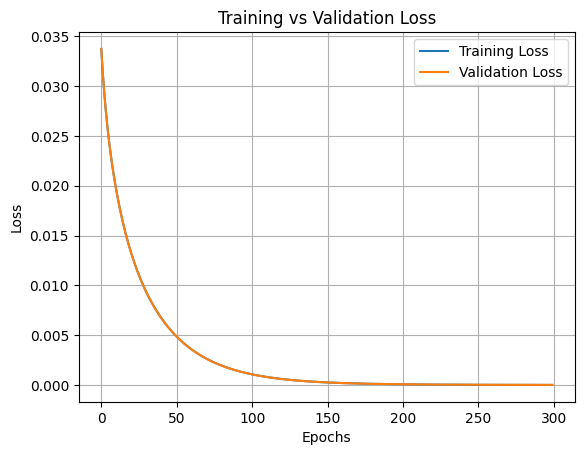

In [9]:
results = model.evals_result()

train_loss = results['validation_0']['logloss']
val_loss   = results['validation_1']['logloss']

plt.figure()
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid()
plt.show()

PermutationExplainer explainer: 1001it [01:25, 11.39it/s]                                                              


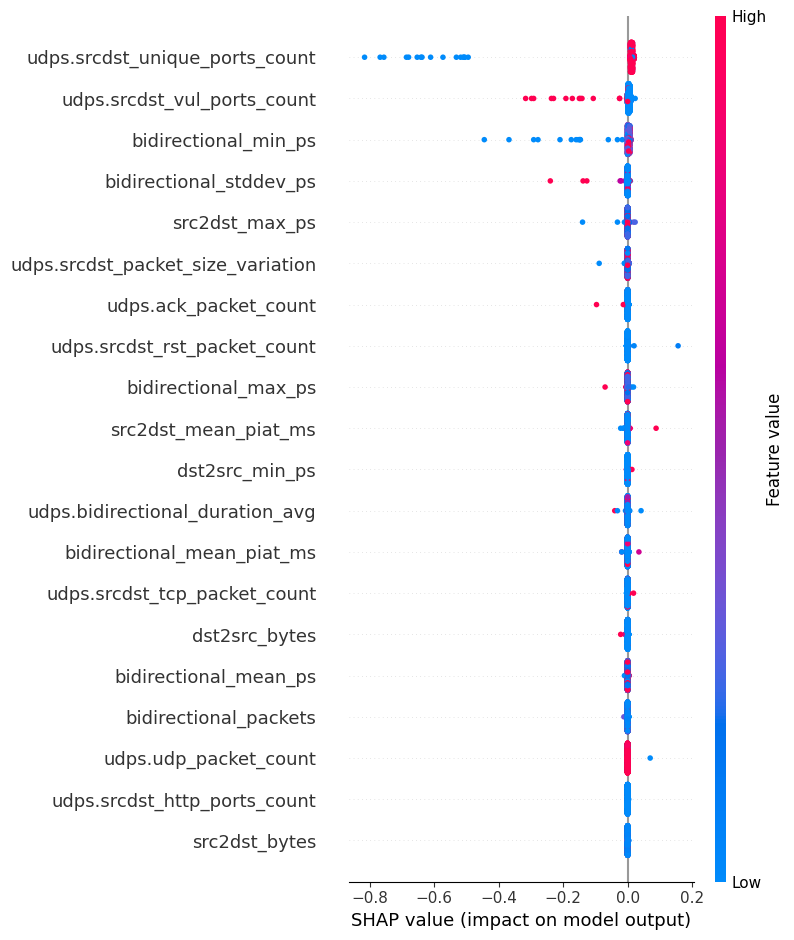

In [10]:
X_sample = X_test.sample(1000, random_state=42)
explainer = shap.Explainer(model.predict, X_sample)
shap_values = explainer(X_sample)
shap.summary_plot(shap_values, X_sample, rng=np.random.default_rng(42))

In [11]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Weighted F1:", f1_score(y_test, y_pred, average='weighted'))
print("Macro F1:", f1_score(y_test, y_pred, average='macro'))
print("ROC-AUC:", roc_auc_score(y_test, y_prob[:,1]))

Accuracy: 0.9999957316168742
Weighted F1: 0.9999957320127909
Macro F1: 0.999905085591572
ROC-AUC: 0.9999999963531441
